In [3]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import os


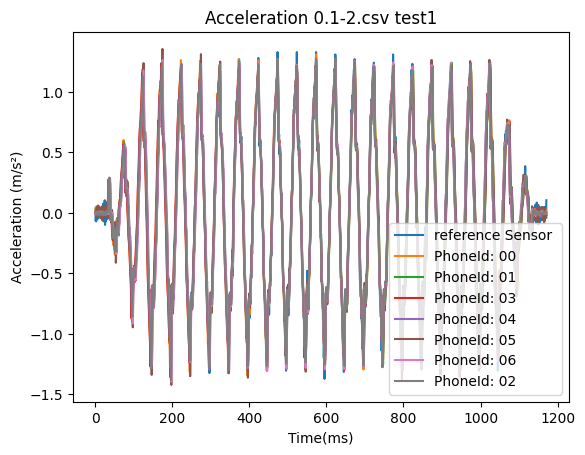

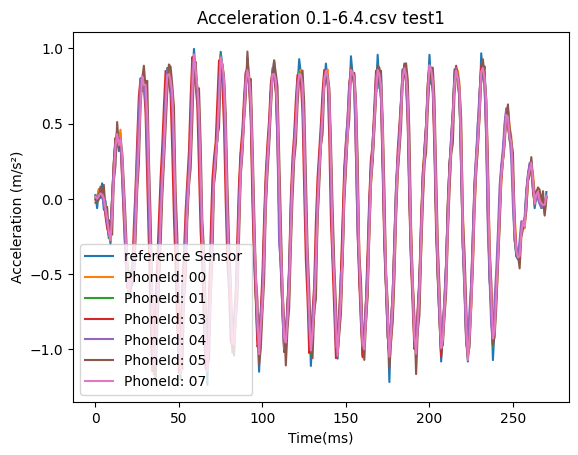

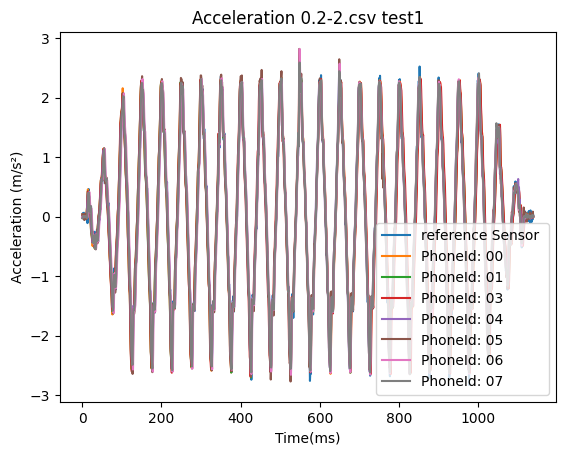

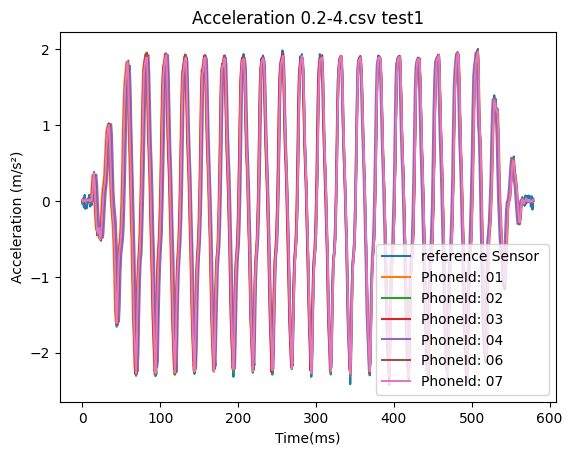

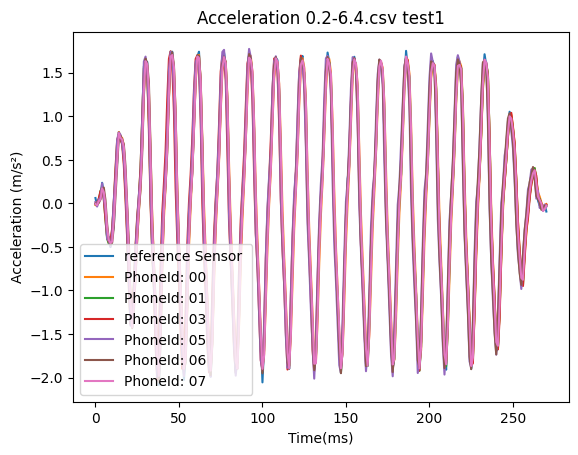

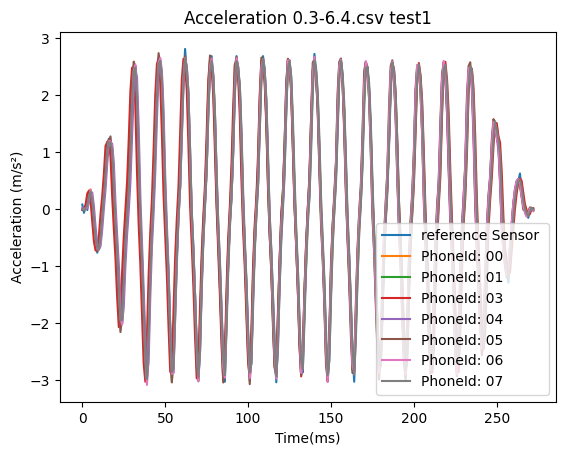

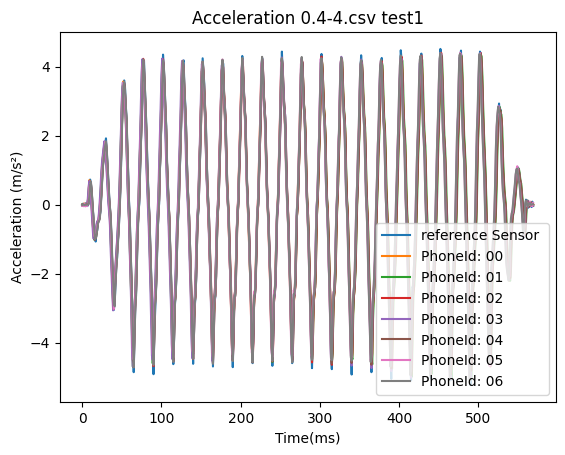

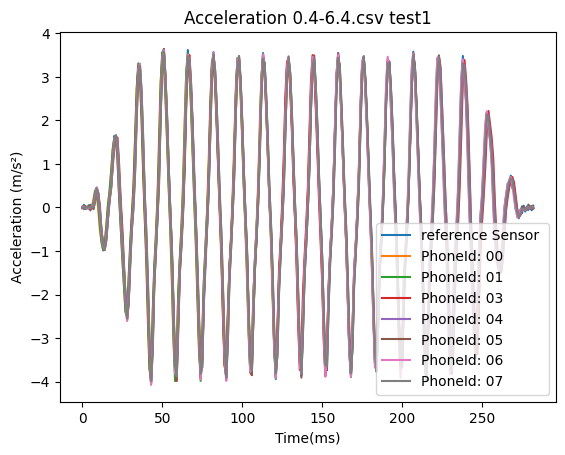

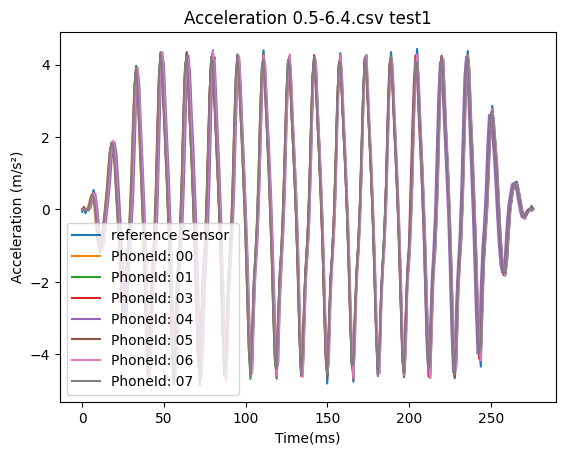

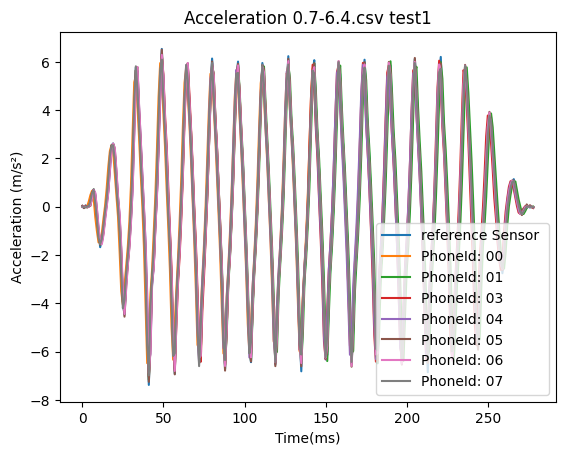

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

directory = 'alignment' 

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):  
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)

        # Make sure column names are strings
        df.columns = df.columns.map(str)
        
        # Check if '11' exists
        if '11' not in df.columns:
            print(f"Column '11' not found in {filename}")
            continue
        
        # Subtract column '11' from all other columns (except '11' itself)
        for col in df.columns:
            if col != '11':
                noise = (df[col]-np.mean(df[col]))
                plt.plot(noise, label=f'PhoneId: {col} ')
            else:
                noise = (df[col]-np.mean(df[col]))
                plt.plot(noise, label=f'reference Sensor ')
                

        plt.xlabel('Time(ms)')
        plt.ylabel('Acceleration (m/s²)')
        plt.title(f'Acceleration {filename} test1')

    
        plt.legend()
        plt.show()



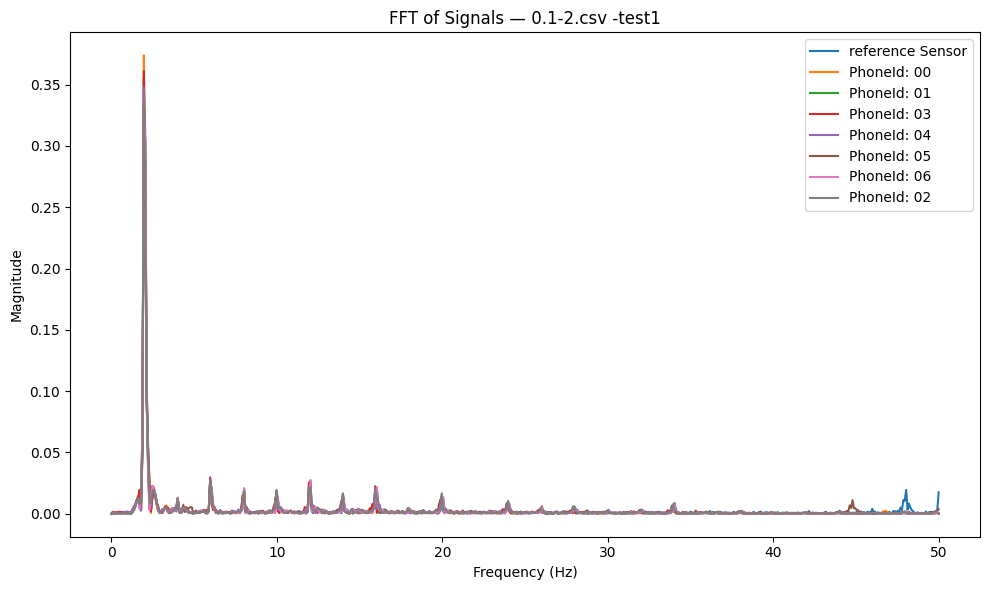

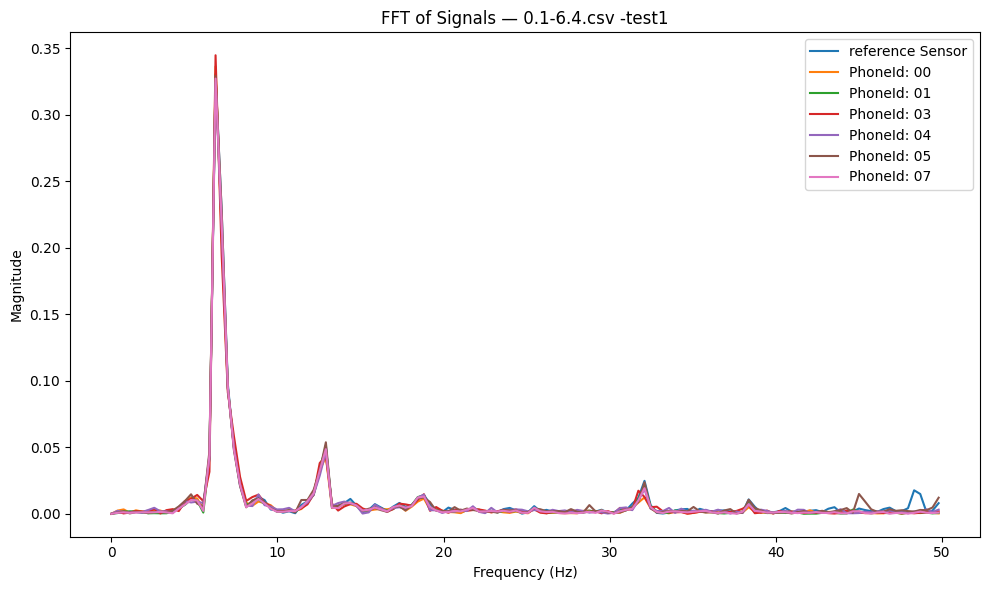

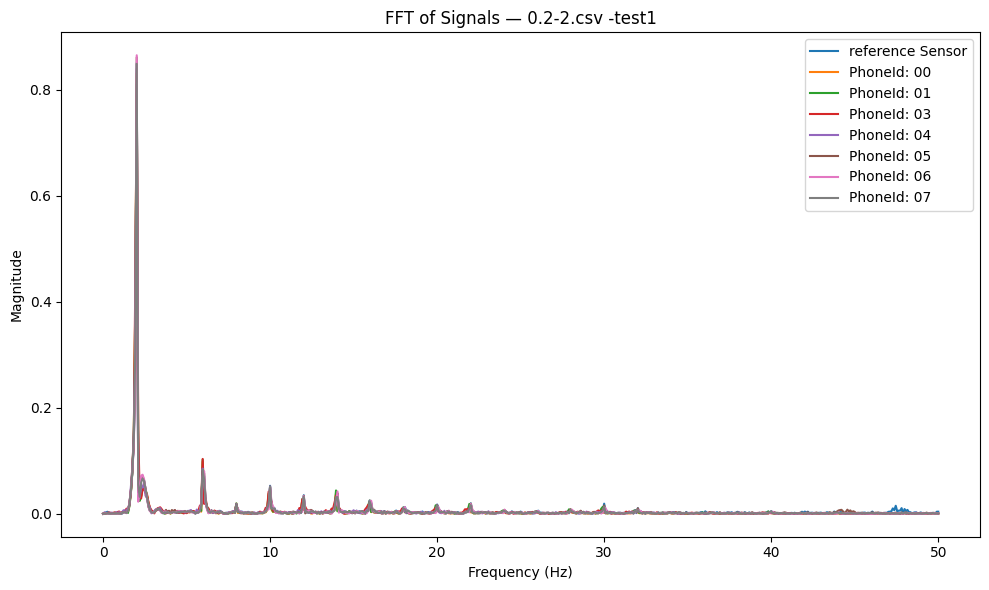

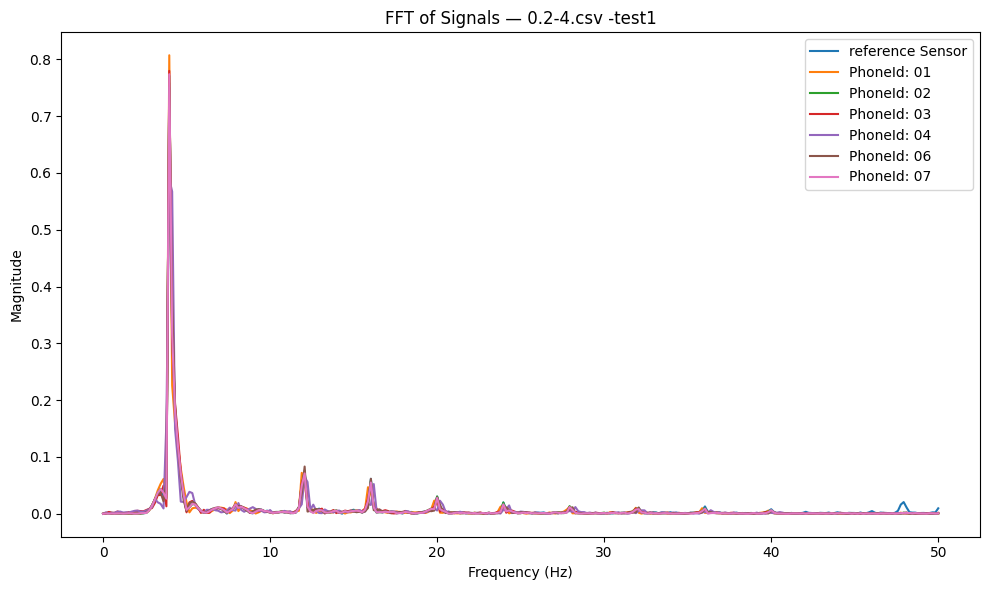

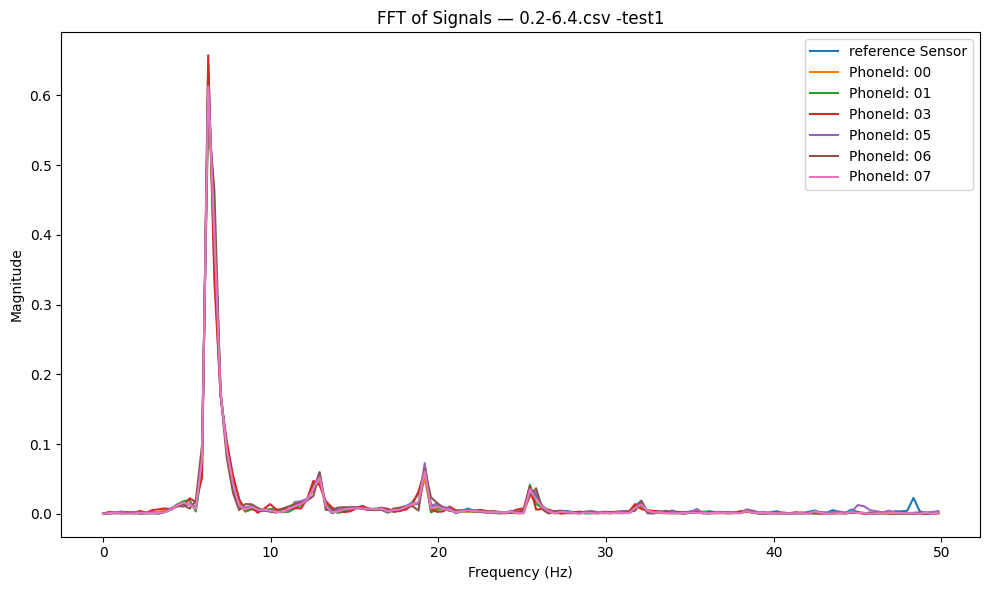

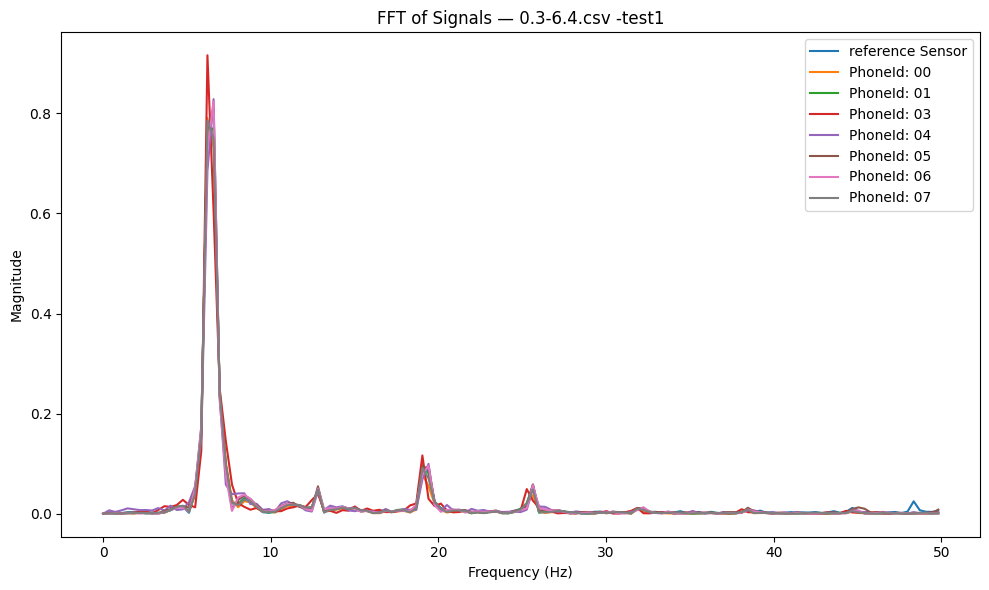

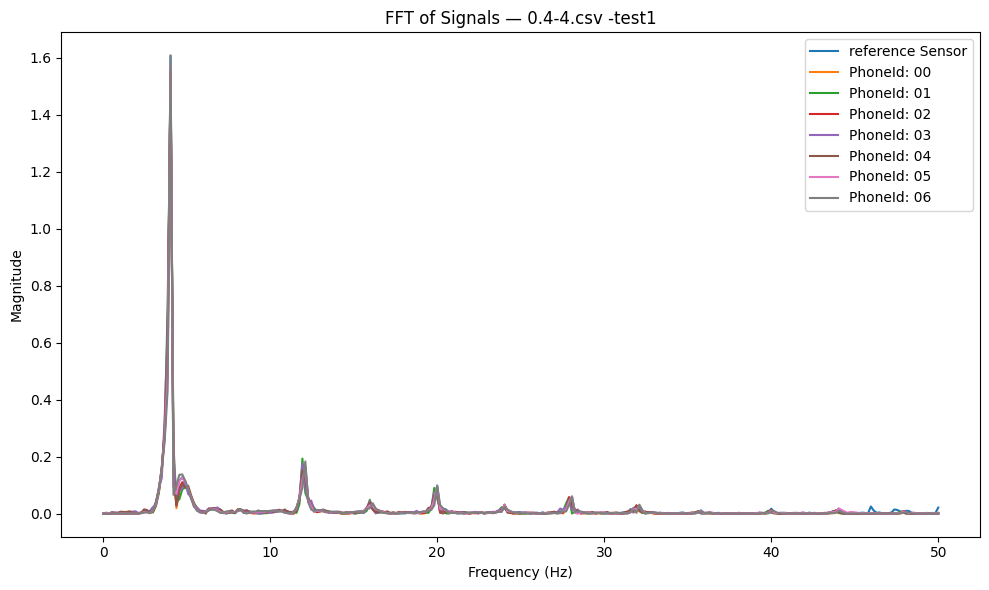

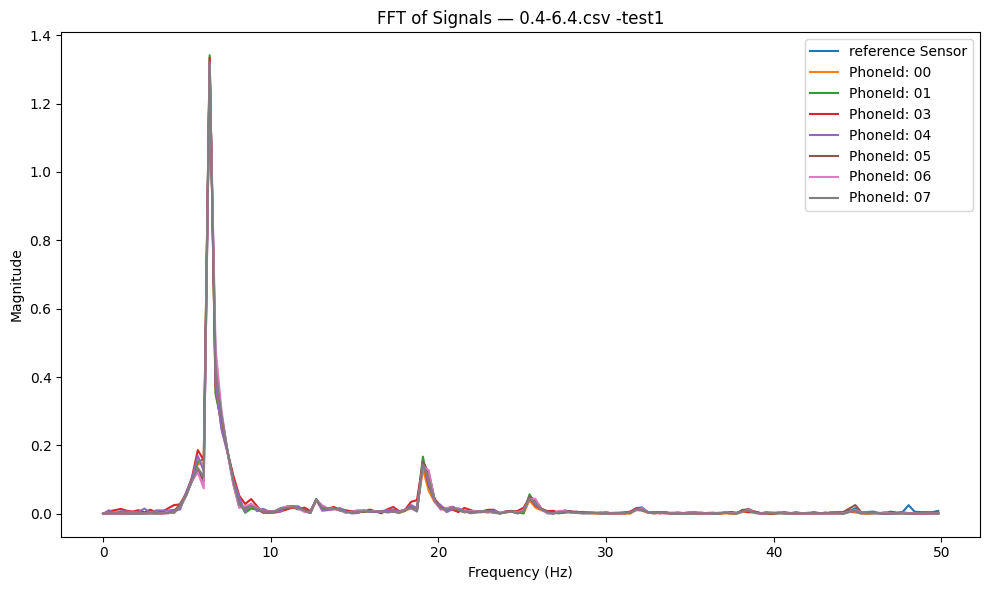

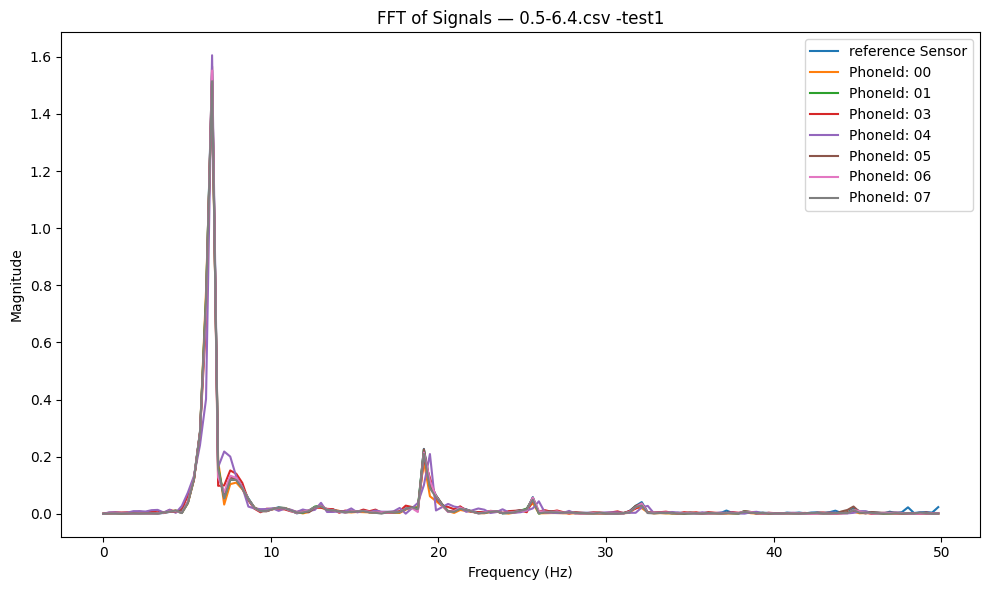

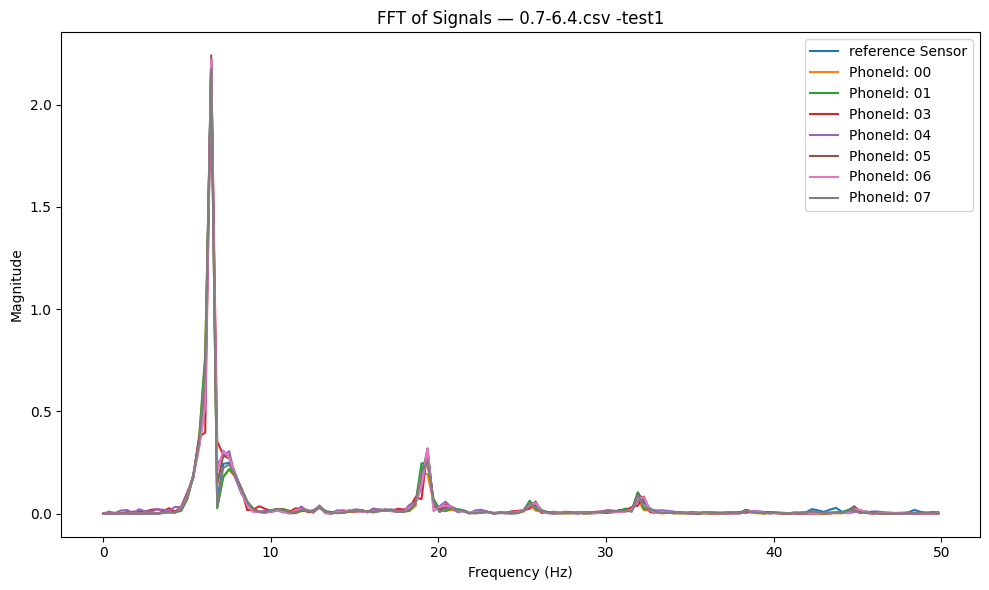

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

directory = 'alignment'
sr = 100  # sampling rate in Hz

# Loop through all files in the directory
for filename in os.listdir(directory):
    if not filename.endswith(".csv"):
        continue

    file_path = os.path.join(directory, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.map(str)

    if '11' not in df.columns:
        print(f"Column '11' not found in {filename}")
        continue

    plt.figure(figsize=(10, 6))

    # Compute FFT for each column
    for col in df.columns:
        # compute zero-mean “noise”
        noise = df[col] - np.mean(df[col])
        N = len(noise)

        # real FFT and corresponding frequency bins
        yf = np.fft.rfft(noise)
        xf = np.fft.rfftfreq(N, d=1/sr)

        # magnitude spectrum (absolute value)
        magnitude = np.abs(yf) / N

        label = 'reference Sensor' if col == '11' else f'PhoneId: {col}'
        plt.plot(xf, magnitude, label=label)

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(f'FFT of Signals — {filename} -test1')
    plt.legend()
    plt.tight_layout()
    plt.show()


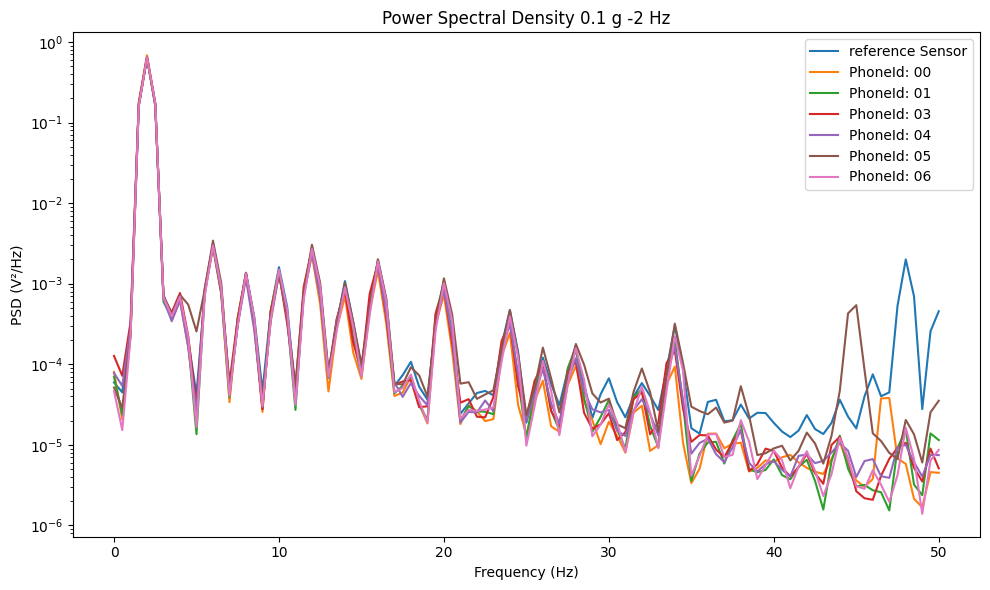

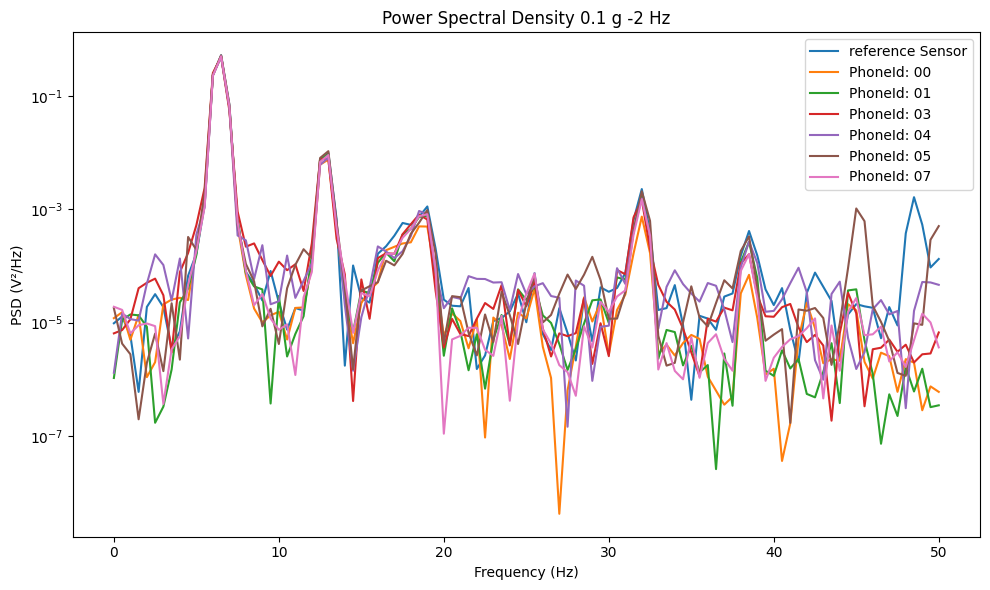

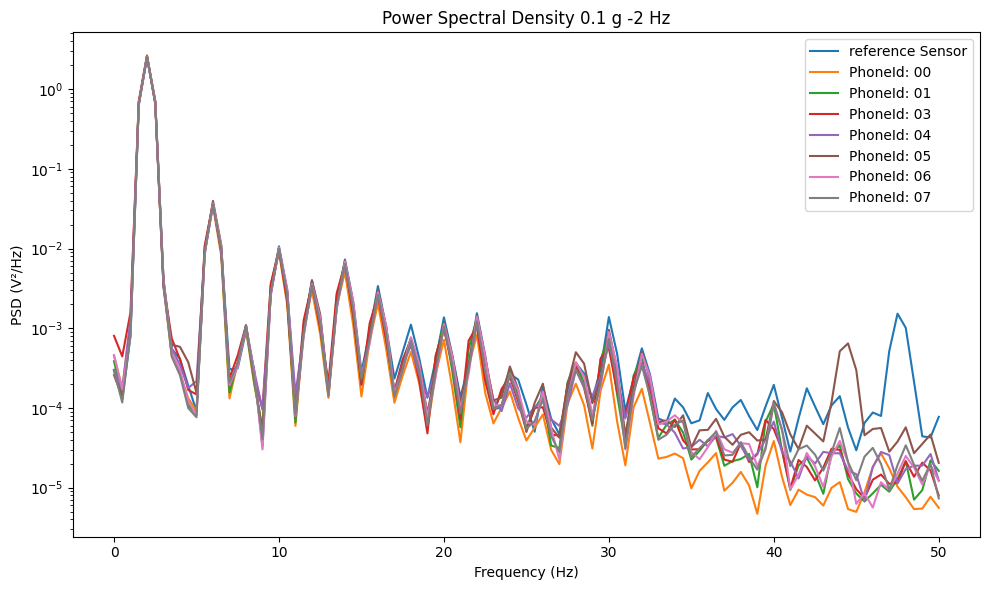

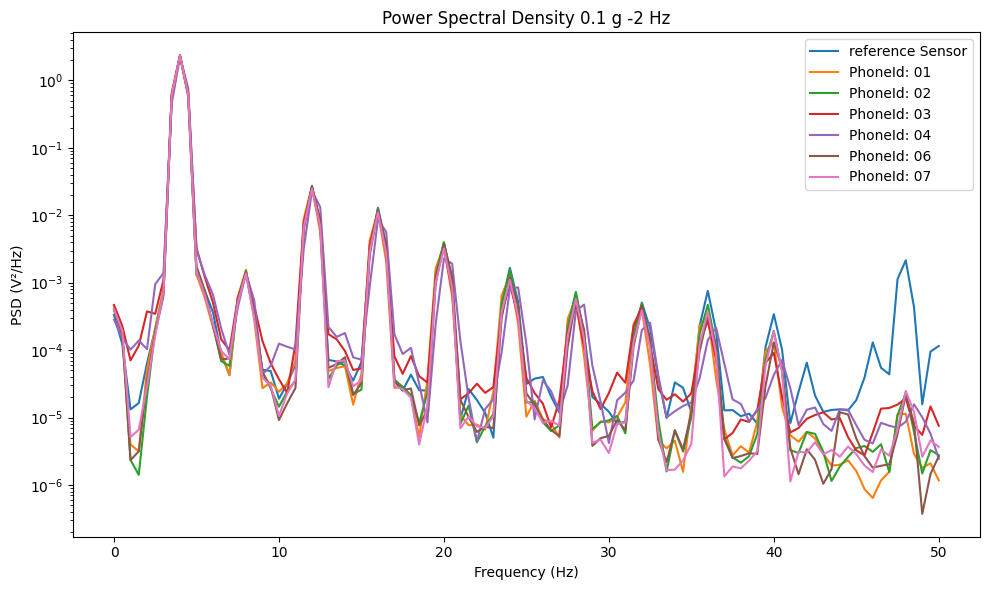

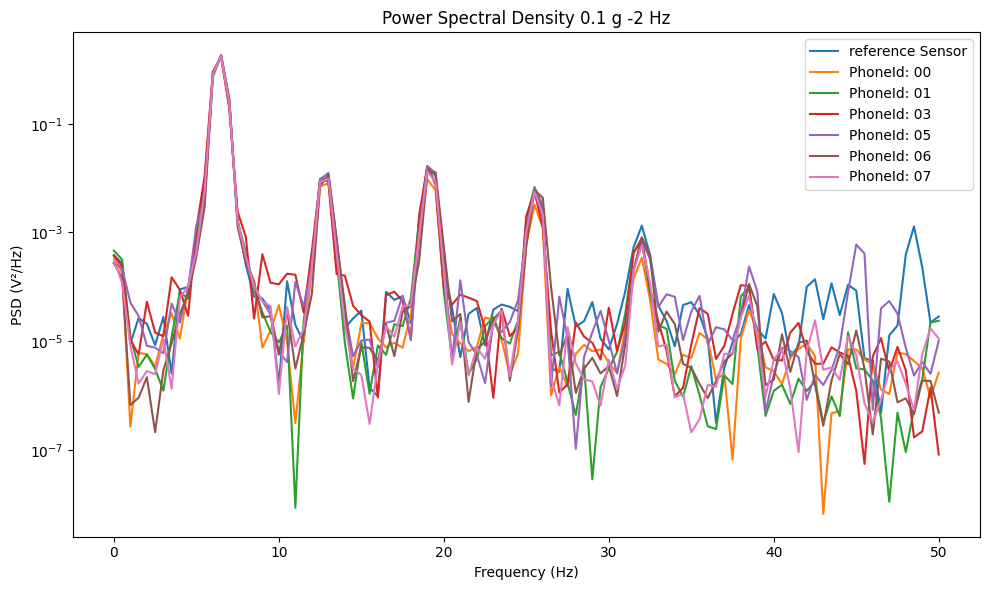

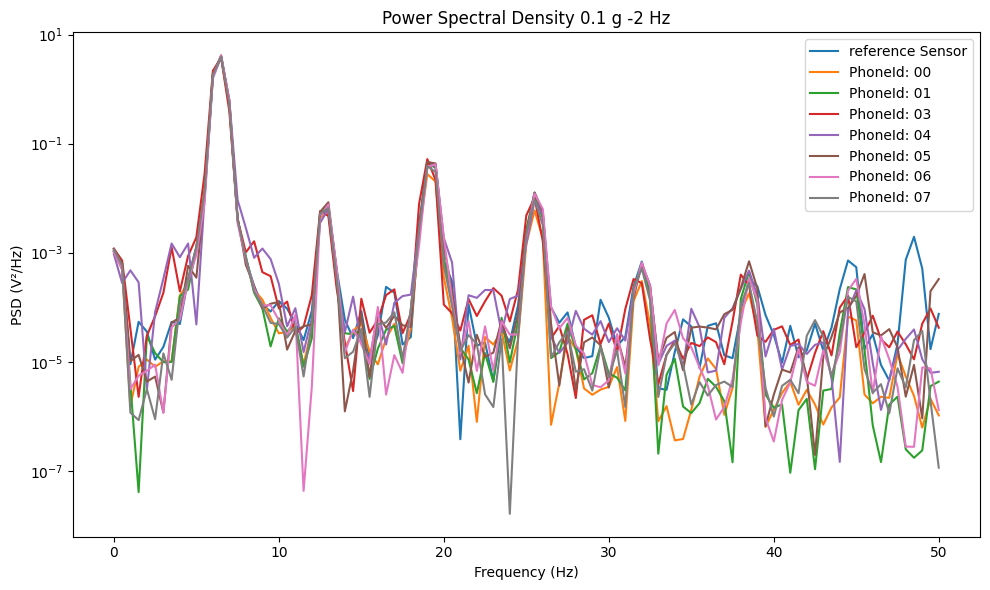

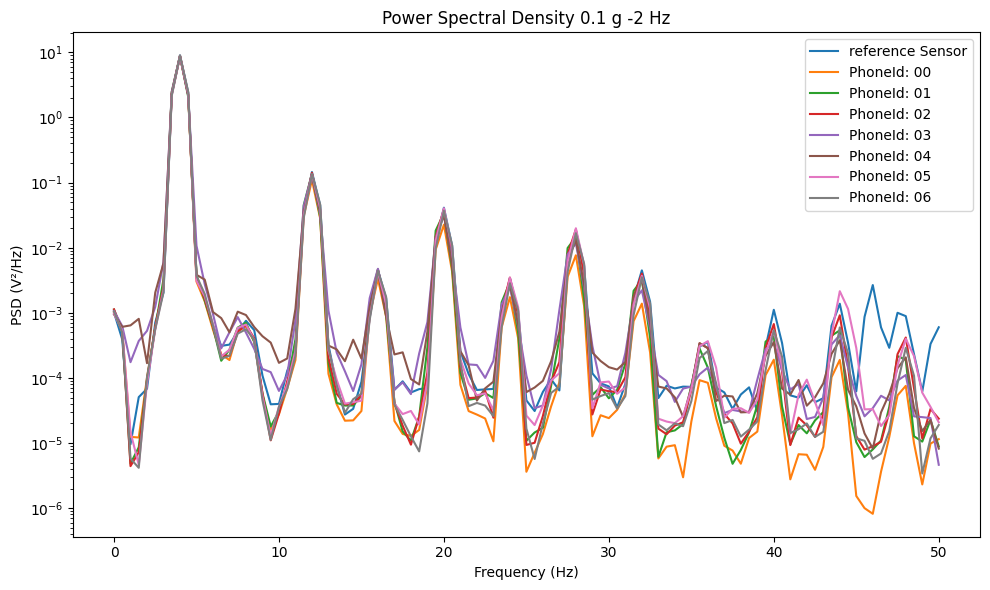

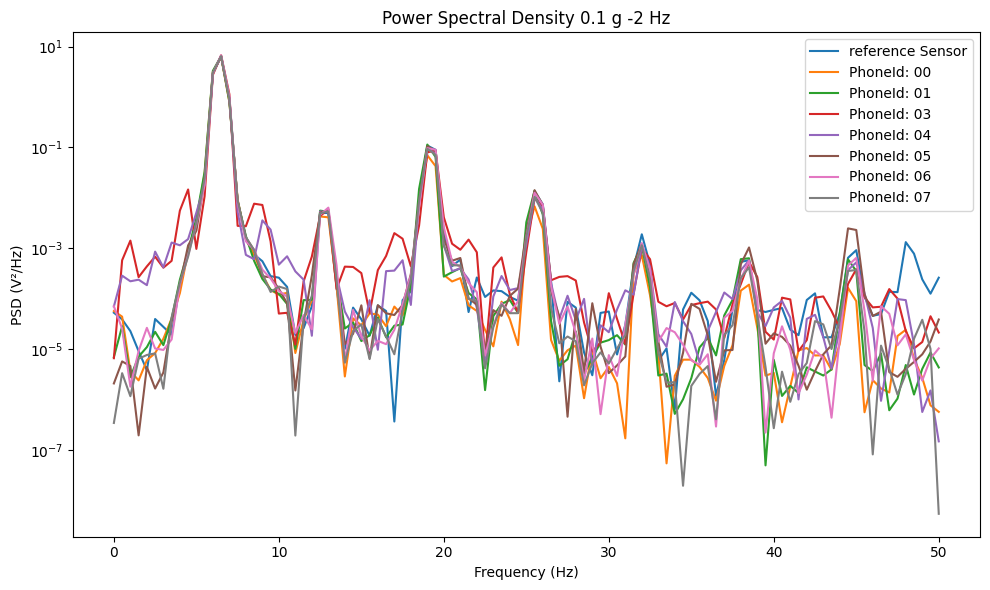

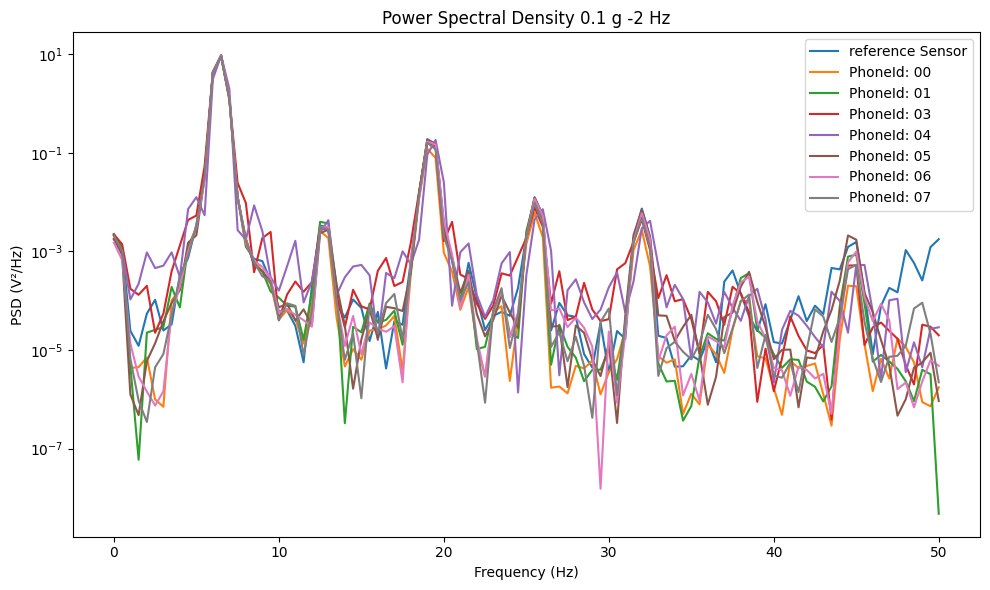

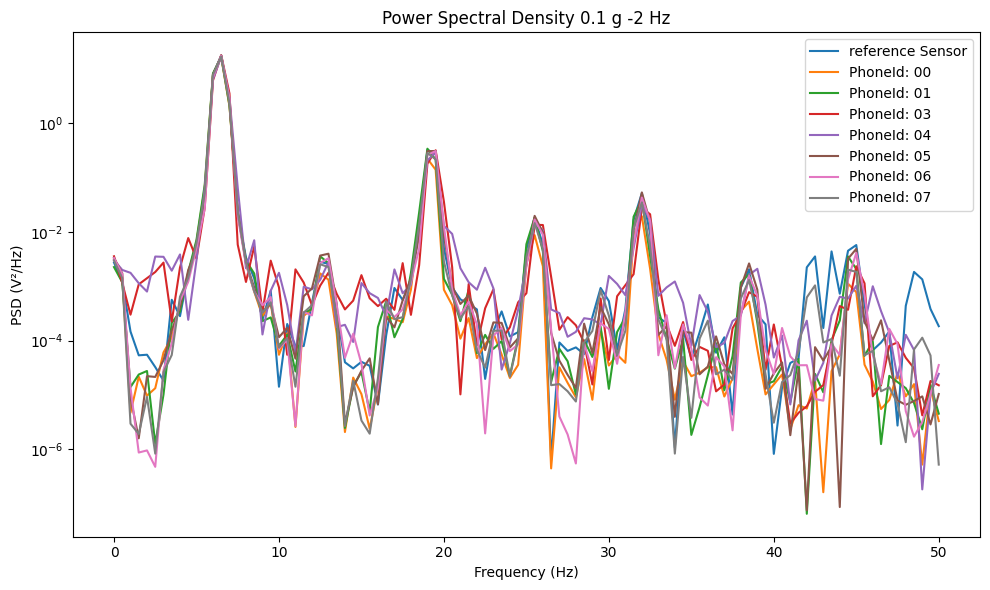

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

directory = 'alignment'
sr = 100  # sampling rate in Hz

for filename in os.listdir(directory):
    if not filename.endswith(".csv"):
        continue

    file_path = os.path.join(directory, filename)
    df = pd.read_csv(file_path)
    df.columns = df.columns.map(str)

    if '11' not in df.columns:
        print(f"Column '11' not found in {filename}")
        continue

    plt.figure(figsize=(10, 6))

    # Compute and plot PSD for each column
    for col in df.columns:
        noise = df[col] - np.mean(df[col])
        # Welch’s PSD estimate
        f, Pxx = welch(noise, fs=sr, nperseg=sr*2)  # 2-second segments
        
        label = 'reference Sensor' if col == '11' else f'PhoneId: {col}'
        plt.semilogy(f, Pxx, label=label)  # log-scale PSD

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (V²/Hz)')
    plt.title(f'Power Spectral Density — {filename}')
    plt.legend()
    plt.tight_layout()
    plt.show()


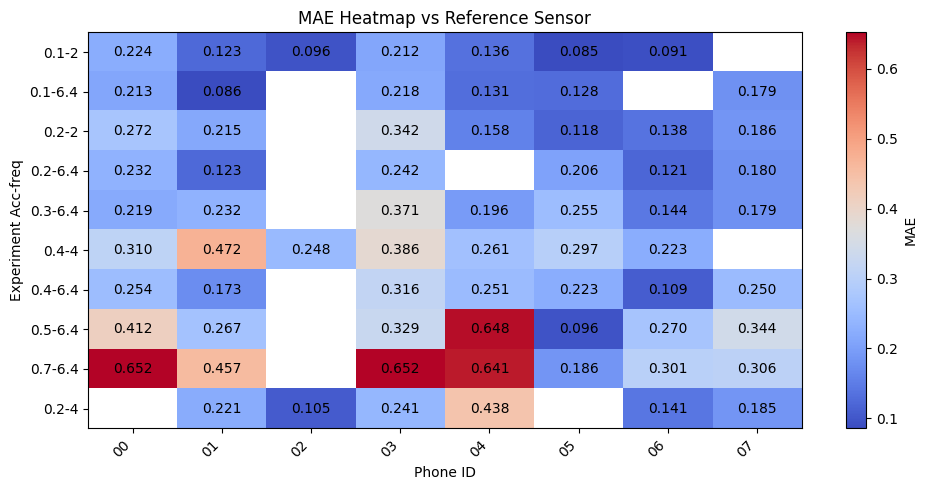

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Directory containing your CSV files
directory = 'alignment'

# Dictionary to hold MAE values per file
mae_dicts = {}
all_cols = set()

# Loop through CSV files and compute MAE for each sensor column vs '11'
for filename in sorted(os.listdir(directory)):
    if filename.endswith('.csv'):
        path = os.path.join(directory, filename)
        df = pd.read_csv(path)
        df.columns = df.columns.map(str)
        
        if '11' not in df.columns:
            continue
        
        cols = [c for c in df.columns if c != '11']
        errors = {}
        for c in cols:
            mae = np.abs(df[c] - df['11']).mean()
            errors[c] = mae
            all_cols.add(c)
        
        mae_dicts[filename.replace(".csv", "")] = errors

# Build a DataFrame from the MAE dictionaries
all_cols = sorted(all_cols)
mae_df = pd.DataFrame.from_dict(mae_dicts, orient='index', columns=all_cols)

# Plot heatmap with annotations
fig, ax = plt.subplots(figsize=(10, max(4, len(mae_df) * 0.5)))
cax = ax.imshow(mae_df.values, aspect='auto', cmap='coolwarm')

fig.colorbar(cax, label='MAE')

ax.set_xticks(np.arange(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(mae_df.index)))
ax.set_yticklabels(mae_df.index)

ax.set_xlabel('Phone ID')
ax.set_ylabel('Experiment Acc-freq')
ax.set_title('MAE Heatmap vs Reference Sensor')

# Annotate each cell with its MAE value
for i in range(mae_df.shape[0]):
    for j in range(mae_df.shape[1]):
        if np.isnan(mae_df.iloc[i, j]):
            ax.text(j, i, f"{mae_df.iloc[i, j]:.3f}", ha='center', va='center', color='white')
        else:
            ax.text(j, i, f"{mae_df.iloc[i, j]:.3f}", ha='center', va='center', color='black')
        

plt.tight_layout()
plt.show()





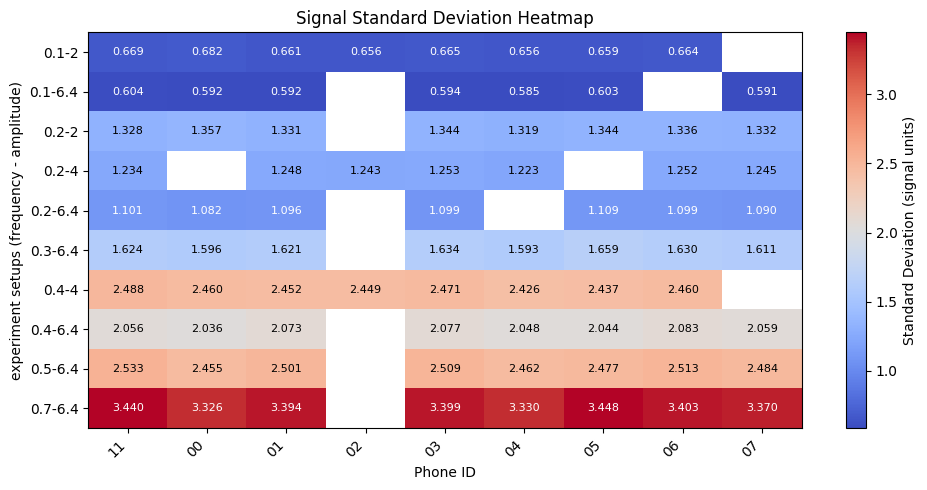

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== CONFIG ====
directory = 'alignment'   # folder with CSVs
REF_COL = '11'            # only used to keep this column first in the display (if present)
CMAP = 'coolwarm'         # same colors as your previous heatmap
# =================

# Collect per-file, per-column standard deviations
std_dicts = {}
all_cols = set()

for filename in sorted(os.listdir(directory)):
    if not filename.endswith('.csv'):
        continue

    path = os.path.join(directory, filename)
    df = pd.read_csv(path)
    df.columns = df.columns.map(str)

    row_values = {}
    for c in df.columns:
        x = pd.to_numeric(df[c], errors='coerce').values  # coerce non-numeric to NaN
        # Standard deviation (centers by the mean internally; ignores NaNs)
        s = np.nanstd(x) if x.size > 0 else np.nan
        row_values[c] = float(s) if np.isfinite(s) else np.nan
        all_cols.add(c)

    std_dicts[filename.replace(".csv", "")] = row_values

# Build DataFrame with all columns encountered
all_cols = sorted(all_cols, key=lambda x: (x != REF_COL, x))  # keep REF_COL first if present
std_df = pd.DataFrame.from_dict(std_dicts, orient='index', columns=all_cols)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, max(4, len(std_df) * 0.5)))

cax = ax.imshow(std_df.values, aspect='auto', cmap=CMAP)
cbar = fig.colorbar(cax)
cbar.set_label("Standard Deviation (signal units)")

ax.set_xticks(np.arange(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(std_df.index)))
ax.set_yticklabels(std_df.index)

ax.set_xlabel('Phone ID')
ax.set_ylabel('experiment setups (frequency - amplitude)')
ax.set_title('Signal Standard Deviation Heatmap')

# Helper for readable text on coolwarm
def text_color_for_value(val):
    rgba = cax.cmap(cax.norm(val if np.isfinite(val) else 0.0))
    r, g, b = rgba[:3]
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'black' if lum > 0.6 else 'white'

# Annotate each cell
for i in range(std_df.shape[0]):
    for j in range(std_df.shape[1]):
        v = std_df.iloc[i, j]
        if np.isnan(v):
            txt, color = "NaN", 'white'
        else:
            txt, color = f"{v:.3f}", text_color_for_value(v)
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()


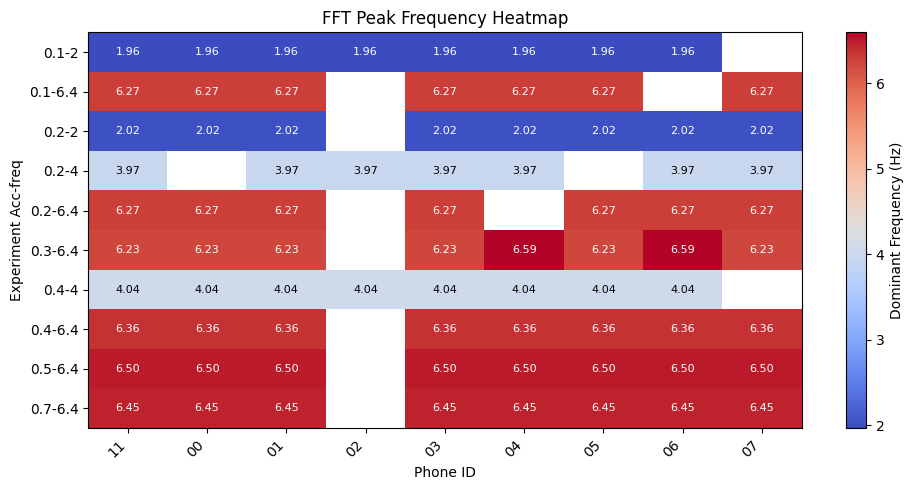

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== CONFIG ====
directory = 'alignment'   # folder with CSVs
REF_COL = '11'            # reference sensor column
FS = 100.0                # sampling rate (Hz)
MODE = "freq"             # "freq" -> dominant freq (Hz); "delta_vs_ref" -> phone_freq - ref_freq (Hz)
MIN_FREQ_HZ = 0.1         # ignore DC / ultra-low
CMAP = 'coolwarm'         # same colors as your MAE heatmap
# =================

def dominant_frequency(x, fs, min_freq=0.0):
    """Return dominant (peak) frequency in Hz using rFFT, ignoring bins below min_freq."""
    x = np.asarray(x, dtype=float)
    if x.size < 4 or np.all(np.isnan(x)):
        return np.nan

    # Remove mean and handle NaNs
    x = np.nan_to_num(x - np.nanmean(x))

    # Hann window to reduce leakage
    w = np.hanning(len(x))
    xw = x * w

    # rFFT
    spec = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(len(xw), d=1.0/fs)
    mag = np.abs(spec)

    # Mask low frequencies
    mask = freqs >= min_freq
    if not np.any(mask):
        return np.nan

    peak_idx = np.argmax(mag[mask])
    peak_freq = freqs[mask][peak_idx]
    return float(peak_freq)

# Collect dominant frequencies per file/column (INCLUDING 11)
domfreq_dicts = {}
all_cols = set()

for filename in sorted(os.listdir(directory)):
    if not filename.endswith('.csv'):
        continue

    path = os.path.join(directory, filename)
    df = pd.read_csv(path)
    df.columns = df.columns.map(str)

    # If MODE needs a reference but it's missing, skip this file
    if MODE == "delta_vs_ref" and REF_COL not in df.columns:
        continue

    cols = list(df.columns)  # include ALL columns, including '11'
    row_values = {}

    # Compute reference dominant frequency if needed
    ref_freq = None
    if MODE == "delta_vs_ref":
        ref_freq = dominant_frequency(df[REF_COL].values, FS, min_freq=MIN_FREQ_HZ)

    for c in cols:
        f_dom = dominant_frequency(df[c].values, FS, min_freq=MIN_FREQ_HZ)

        if MODE == "freq":
            val = f_dom
        elif MODE == "delta_vs_ref":
            if c == REF_COL:
                val = 0.0 if np.isfinite(ref_freq) else np.nan
            else:
                val = f_dom - ref_freq if np.isfinite(f_dom) and np.isfinite(ref_freq) else np.nan
        else:
            raise ValueError("MODE must be 'freq' or 'delta_vs_ref'.")

        row_values[c] = val
        all_cols.add(c)

    domfreq_dicts[filename.replace(".csv", "")] = row_values

# Build DataFrame with all columns encountered
all_cols = sorted(all_cols, key=lambda x: (x != REF_COL, x))  # keep '11' first if you like; remove if not desired
freq_df = pd.DataFrame.from_dict(domfreq_dicts, orient='index', columns=all_cols)

# Plot heatmap with the SAME colormap
fig, ax = plt.subplots(figsize=(10, max(4, len(freq_df) * 0.5)))

# Color scaling
if MODE == "delta_vs_ref":
    vabs = np.nanmax(np.abs(freq_df.values))
    vmin, vmax = (-vabs, vabs) if np.isfinite(vabs) else (None, None)
    cax = ax.imshow(freq_df.values, aspect='auto', cmap=CMAP, vmin=vmin, vmax=vmax)
else:
    cax = ax.imshow(freq_df.values, aspect='auto', cmap=CMAP)

cbar_label = "Dominant Frequency (Hz)" if MODE == "freq" else "Δ Dominant Frequency vs Ref (Hz)"
cbar = fig.colorbar(cax)
cbar.set_label(cbar_label)

ax.set_xticks(np.arange(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(freq_df.index)))
ax.set_yticklabels(freq_df.index)

ax.set_xlabel('Phone ID')
ax.set_ylabel('Experiment Acc-freq')
title_suffix = "" if MODE == "freq" else " (Δ vs Ref)"
ax.set_title(f'FFT Peak Frequency Heatmap{title_suffix}')

# Helper for readable text on coolwarm
def text_color_for_value(val):
    rgba = cax.cmap(cax.norm(val))
    r, g, b = rgba[:3]
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'black' if lum > 0.6 else 'white'

# Annotate each cell
for i in range(freq_df.shape[0]):
    for j in range(freq_df.shape[1]):
        v = freq_df.iloc[i, j]
        if np.isnan(v):
            txt, color = "NaN", 'white'
        else:
            txt, color = f"{v:.2f}", text_color_for_value(v)
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()



In [10]:
mae_df.iloc[i, j].isna

AttributeError: 'numpy.float64' object has no attribute 'isna'

In [1]:

# Function to compute max value, sampling rate, and argmax of FFT for Acceleration x
def process_file(file_path):
    # Read the data into a DataFrame
    df = pd.read_excel(file_path, sheet_name='Accelerometer')

    # Extract the Time and Acceleration x columns
    time = df['Time (s)']
    accel_x = df['Acceleration x (m/s^2)']


    # Compute the sampling rate (assuming uniform sampling in time)
    sampling_interval = np.mean(np.diff(time))  # Time difference between samples
    sampling_rate = 1 / sampling_interval  # Sampling frequency

    # Perform FFT on Acceleration x
    fft_values = np.fft.fft(accel_x)
    fft_frequencies = np.fft.fftfreq(len(accel_x), sampling_interval)

    # Only consider the positive frequencies
    positive_frequencies = fft_frequencies[fft_frequencies >= 0]
    positive_fft_values = np.abs(fft_values[fft_frequencies >= 0])

    # Find the maximum value of Acceleration x and the dominant frequency
    max_accel_x = np.max(accel_x)
    max_index = np.argmax(positive_fft_values)
    dominant_frequency = positive_frequencies[max_index]
    mean_acc = np.mean(accel_x)

    return max_accel_x, dominant_frequency, sampling_rate, mean_acc

In [ ]:
directory = 'SE' 
# Loop through all files in the directory
for filename in os.listdir(directory):
    
    if filename.endswith(".xls"):  # Assuming .xlsx format
        
        file_path = os.path.join(directory, filename)
        print(file_path)
        # Process the file and get the results
        max_accel_x, dominant_frequency, sampling_rate, mean_acc = process_file(file_path)


        # Print the results
        print(f"File: {filename}")
        print(f"Maximum Acceleration x: {max_accel_x}")
        print(f"Dominant Frequency: {dominant_frequency} Hz")
        print(f"Sampling Rate: {sampling_rate} Hz")
        print("-" * 50)


SE\07-0.1-6.4.csv
File: 07-0.1-6.4.csv
Maximum Acceleration x: 1.122964783
Dominant Frequency: 6.406576203219316 Hz
Sampling Rate: 100.06461879313979 Hz
--------------------------------------------------
SE\07-0.2-2.csv
File: 07-0.2-2.csv
Maximum Acceleration x: 2.757715302
Dominant Frequency: 2.009695598046681 Hz
Sampling Rate: 100.06609331940767 Hz
--------------------------------------------------
SE\07-0.2-4.csv
File: 07-0.2-4.csv
Maximum Acceleration x: 2.128274231
Dominant Frequency: 4.015063579183659 Hz
Sampling Rate: 100.06773843503889 Hz
--------------------------------------------------
SE\07-0.2-6.4.csv
File: 07-0.2-6.4.csv
Maximum Acceleration x: 1.86976181
Dominant Frequency: 6.497965562570423 Hz
Sampling Rate: 100.06866966358452 Hz
--------------------------------------------------
SE\07-0.3-6.4.csv
File: 07-0.3-6.4.csv
Maximum Acceleration x: 2.80591507
Dominant Frequency: 6.333385843066748 Hz
Sampling Rate: 100.06749632045461 Hz
-----------------------------------------

In [2]:
import numpy as np
from scipy.signal import correlate

# Assuming mobile_signal and sensor_signal are your data arrays
def align_signals(signal1, signal2):
    correlation = correlate(signal1, signal2, mode='full')
    lag = correlation.argmax() - (len(signal2) - 1)
    print(lag)

    # Correct the time shift
    if lag > 0:
        corrected_signal1 = signal1[lag:]
        corrected_signal2 = signal2[:len(corrected_signal1)]
    else:
        corrected_signal2 = signal2[-lag:]
        corrected_signal1 = signal1[:len(corrected_signal2)]

    return corrected_signal1, corrected_signal2



In [ ]:
import os
import pandas as pd
from scipy.signal import resample
# Directory containing the generated _normalcomb.csv files
directory = os.getcwd()  # Replace with your directory path
orginal=[]
edited = []

# Extract the 'input' and 'label' columns as 1D numpy arrays
X1 = pd.read_csv("A5(1)/03-0.2-2.CSV")['Acceleration x (m/s^2)'].values
X2 = pd.read_csv("A5(2)/04-0.2-2.CSV")['Acceleration x (m/s^2)'].values
y = pd.read_csv("sensor/11-0.2-2.csv")['Acceleration x (m/s^2)'].values
# Original sample rate
original_rate1 = 197  # Hz
original_rate2 = 196  # Hz
new_rate = 100  # Hz

# Resample the signal to the new rate
num_samples1 = int(len(X1) * new_rate / original_rate1)
X_resampled = resample(X1, num_samples1)

# Resample the signal to the new rate
num_samples2 = int(len(X2) * new_rate / original_rate2)
X_resampled = resample(X2, num_samples2)

# Use the function to get the aligned signals
X1i, yi = align_signals(X_resampled, y)
        


52



=== Time-Domain Standard Deviation (AS-IS) Table ===
              11       00       01       02       03       04       05       06       07
0.1-2   0.669326 0.682087 0.660855 0.655848 0.665095 0.655968 0.658958 0.663785      NaN
0.1-6.4 0.603885 0.592484 0.592480      NaN 0.593605 0.584727 0.602679      NaN 0.591081
0.2-2   1.328107 1.357278 1.331348      NaN 1.343660 1.318791 1.343501 1.336081 1.331844
0.2-4   1.234255      NaN 1.247540 1.242830 1.253411 1.223479      NaN 1.251845 1.245327
0.2-6.4 1.101036 1.082323 1.095845      NaN 1.098604      NaN 1.109062 1.099327 1.089678
0.3-6.4 1.624216 1.595705 1.621163      NaN 1.633555 1.593372 1.659369 1.630269 1.611410
0.4-4   2.487556 2.459535 2.452338 2.448902 2.471245 2.425521 2.436874 2.459960      NaN
0.4-6.4 2.056314 2.036254 2.073495      NaN 2.077329 2.047531 2.044093 2.082612 2.059149
0.5-6.4 2.532501 2.454878 2.500528      NaN 2.509339 2.462048 2.477383 2.513082 2.484070
0.7-6.4 3.439988 3.326465 3.393816      NaN 3.399463 3.3

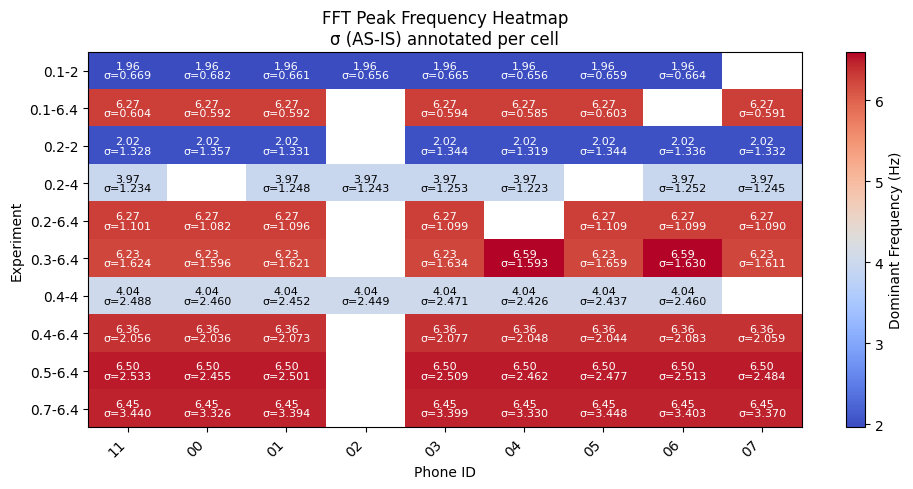

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== CONFIG ====
directory = 'alignment'   # folder with CSVs
REF_COL = '11'            # reference sensor column
FS = 100.0                # sampling rate (Hz)
MODE = "freq"             # "freq" -> dominant freq (Hz); "delta_vs_ref" -> phone_freq - ref_freq (Hz)
MIN_FREQ_HZ = 0.1         # ignore DC / ultra-low
CMAP = 'coolwarm'         # same colors as your MAE heatmap
SAVE_STD_CSV = True       # also save the std table as CSV
STD_CSV_PATH = 'std_table_as_is.csv'
# =================

def dominant_frequency(x, fs, min_freq=0.0):
    """Return dominant (peak) frequency in Hz using rFFT, ignoring bins below min_freq."""
    x = np.asarray(x, dtype=float)
    if x.size < 4 or np.all(np.isnan(x)):
        return np.nan

    # Remove mean and handle NaNs for spectral peak detection
    x = np.nan_to_num(x - np.nanmean(x))

    # Hann window to reduce leakage
    w = np.hanning(len(x))
    xw = x * w

    # rFFT
    spec = np.fft.rfft(xw)
    freqs = np.fft.rfftfreq(len(xw), d=1.0/fs)
    mag = np.abs(spec)

    # Mask low frequencies
    mask = freqs >= min_freq
    if not np.any(mask):
        return np.nan

    peak_idx = np.argmax(mag[mask])
    peak_freq = freqs[mask][peak_idx]
    return float(peak_freq)

# Collect dominant frequencies and time-domain std (AS-IS) per file/column
domfreq_dicts = {}
std_dicts = {}
all_cols = set()

for filename in sorted(os.listdir(directory)):
    if not filename.endswith('.csv'):
        continue

    path = os.path.join(directory, filename)
    df = pd.read_csv(path)
    df.columns = df.columns.map(str)

    # If MODE needs a reference but it's missing, skip this file
    if MODE == "delta_vs_ref" and REF_COL not in df.columns:
        continue

    cols = list(df.columns)  # include ALL columns
    row_freq_values = {}
    row_std_values = {}

    # Compute reference dominant frequency if needed
    ref_freq = None
    if MODE == "delta_vs_ref":
        ref_freq = dominant_frequency(df[REF_COL].values, FS, min_freq=MIN_FREQ_HZ)

    for c in cols:
        # Dominant frequency
        f_dom = dominant_frequency(df[c].values, FS, min_freq=MIN_FREQ_HZ)

        if MODE == "freq":
            val = f_dom
        elif MODE == "delta_vs_ref":
            if c == REF_COL:
                val = 0.0 if np.isfinite(ref_freq) else np.nan
            else:
                val = f_dom - ref_freq if np.isfinite(f_dom) and np.isfinite(ref_freq) else np.nan
        else:
            raise ValueError("MODE must be 'freq' or 'delta_vs_ref'.")

        row_freq_values[c] = val

        # Time-domain STD (AS-IS; no mean removal, no filtering)
        x_raw = np.asarray(df[c].values, dtype=float)
        sigma = np.nanstd(x_raw) if x_raw.size > 0 else np.nan
        row_std_values[c] = float(sigma) if np.isfinite(sigma) else np.nan

        all_cols.add(c)

    domfreq_dicts[filename.replace(".csv", "")] = row_freq_values
    std_dicts[filename.replace(".csv", "")] = row_std_values

# Build DataFrames with all columns encountered
all_cols = sorted(all_cols, key=lambda x: (x != REF_COL, x))  # keep REF first if desired
freq_df = pd.DataFrame.from_dict(domfreq_dicts, orient='index', columns=all_cols)
std_df  = pd.DataFrame.from_dict(std_dicts,  orient='index', columns=all_cols)

# ====== PRINT / SAVE the STD TABLE ======
print("\n=== Time-Domain Standard Deviation (AS-IS) Table ===")
print(std_df.to_string(float_format=lambda v: f"{v:.6f}"))

if SAVE_STD_CSV:
    std_df.to_csv(STD_CSV_PATH, index=True)
    print(f"\nSaved STD table to: {STD_CSV_PATH}")

# ====== HEATMAP (values = dominant freq or delta), with σ annotated ======
fig, ax = plt.subplots(figsize=(10, max(4, len(freq_df) * 0.5)))

# Color scaling for the frequency layer
if MODE == "delta_vs_ref":
    vabs = np.nanmax(np.abs(freq_df.values))
    vmin, vmax = (-vabs, vabs) if np.isfinite(vabs) else (None, None)
    cax = ax.imshow(freq_df.values, aspect='auto', cmap=CMAP, vmin=vmin, vmax=vmax)
else:
    cax = ax.imshow(freq_df.values, aspect='auto', cmap=CMAP)

cbar_label = "Dominant Frequency (Hz)" if MODE == "freq" else "Δ Dominant Frequency vs Ref (Hz)"
cbar = fig.colorbar(cax)
cbar.set_label(cbar_label)

ax.set_xticks(np.arange(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right')
ax.set_yticks(np.arange(len(freq_df.index)))
ax.set_yticklabels(freq_df.index)

ax.set_xlabel('Phone ID')
ax.set_ylabel('Experiment')
title_suffix = "" if MODE == "freq" else " (Δ vs Ref)"
ax.set_title(f'FFT Peak Frequency Heatmap{title_suffix}\nσ (AS-IS) annotated per cell')

# Helper for readable text on coolwarm
def text_color_for_value(val):
    # If val is nan, choose white text to stand out
    if not np.isfinite(val):
        return 'white'
    rgba = cax.cmap(cax.norm(val))
    r, g, b = rgba[:3]
    # luminance for contrast
    lum = 0.299*r + 0.587*g + 0.114*b
    return 'black' if lum > 0.6 else 'white'

# Annotate each cell with 2 lines:
# line 1: frequency value (or delta)
# line 2: sigma (AS-IS)
for i in range(freq_df.shape[0]):
    for j in range(freq_df.shape[1]):
        v_freq = freq_df.iloc[i, j]
        v_std  = std_df.iloc[i, j]
        if np.isnan(v_freq) and np.isnan(v_std):
            txt = "NaN\nσ=NaN"
            color = 'white'
        else:
            freq_txt = "NaN" if np.isnan(v_freq) else f"{v_freq:.2f}"
            std_txt  = "NaN" if np.isnan(v_std)  else f"{v_std:.3f}"
            txt = f"{freq_txt}\nσ={std_txt}"
            color = text_color_for_value(v_freq)
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=8, linespacing=0.9)

plt.tight_layout()
plt.show()


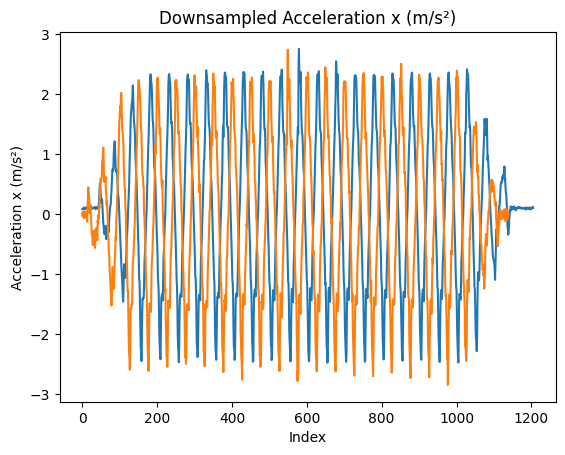

In [8]:
import matplotlib.pyplot as plt
plt.plot(X_resampled)
plt.plot(y)
plt.xlabel('Index')
plt.ylabel('Acceleration x (m/s²)')
plt.title('Downsampled Acceleration x (m/s²)')
plt.show()

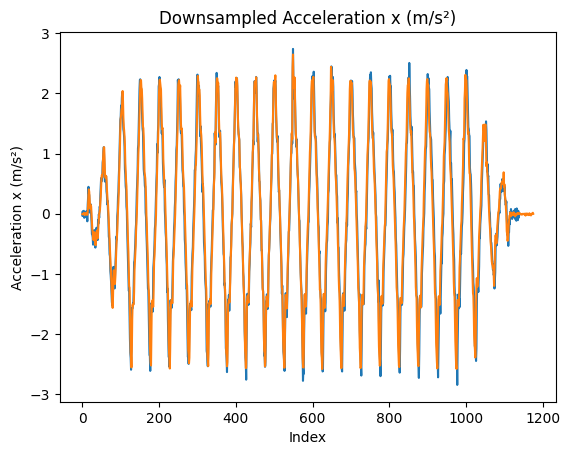

In [7]:
import matplotlib.pyplot as plt
plt.plot(y1)
plt.plot(X1-np.mean(X1))

plt.xlabel('Index')
plt.ylabel('Acceleration x (m/s²)')
plt.title('Downsampled Acceleration x (m/s²)')
plt.savefig('downsampled_acceleration.png')
plt.show()

In [5]:
import os
import pandas as pd
from scipy.signal import resample
# Directory containing the generated _normalcomb.csv files
directory = os.getcwd()  # Replace with your directory path
orginal=[]
edited = []

# Extract the 'input' and 'label' columns as 1D numpy arrays
X = pd.read_csv("A5(2)/04-0.2-2.CSV")['Acceleration x (m/s^2)'].values
y = pd.read_csv("sensor/11-0.2-2.csv")['Acceleration x (m/s^2)'].values
# Original sample rate
original_rate = 197  # Hz
new_rate = 100  # Hz

# Resample the signal to the new rate
num_samples = int(len(X) * new_rate / original_rate)
X_resampled = resample(X, num_samples)

# Use the function to get the aligned signals
X1, y1 = align_signals(X_resampled, y)
        


30


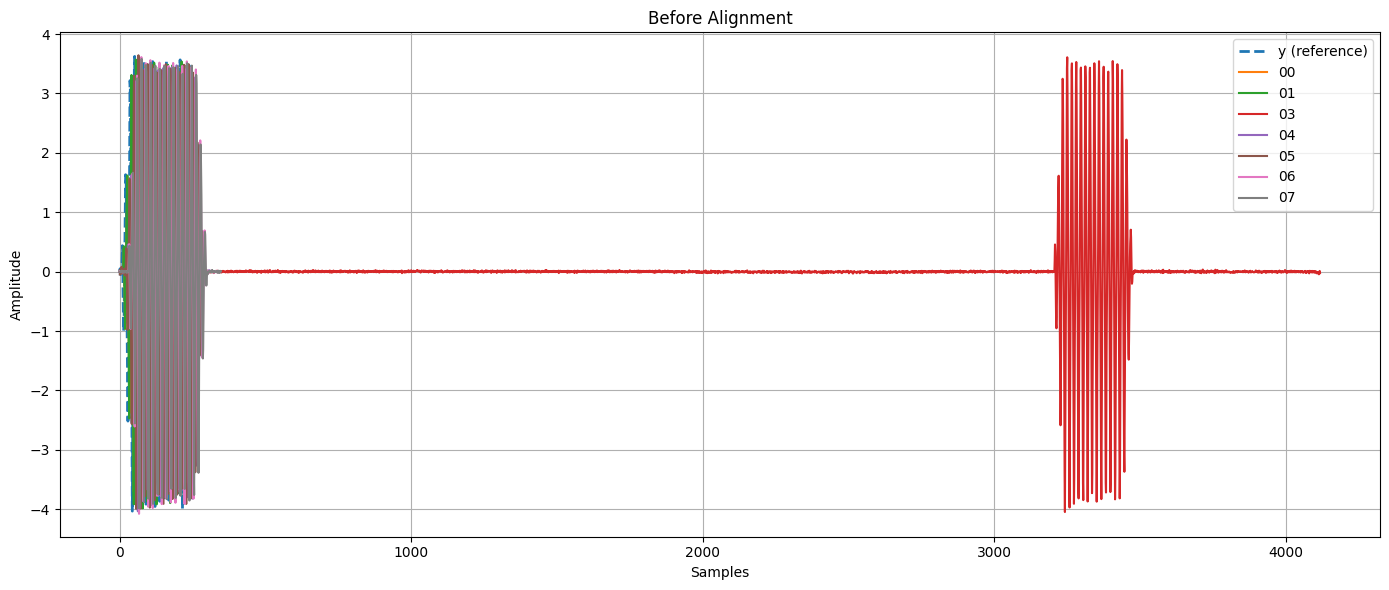

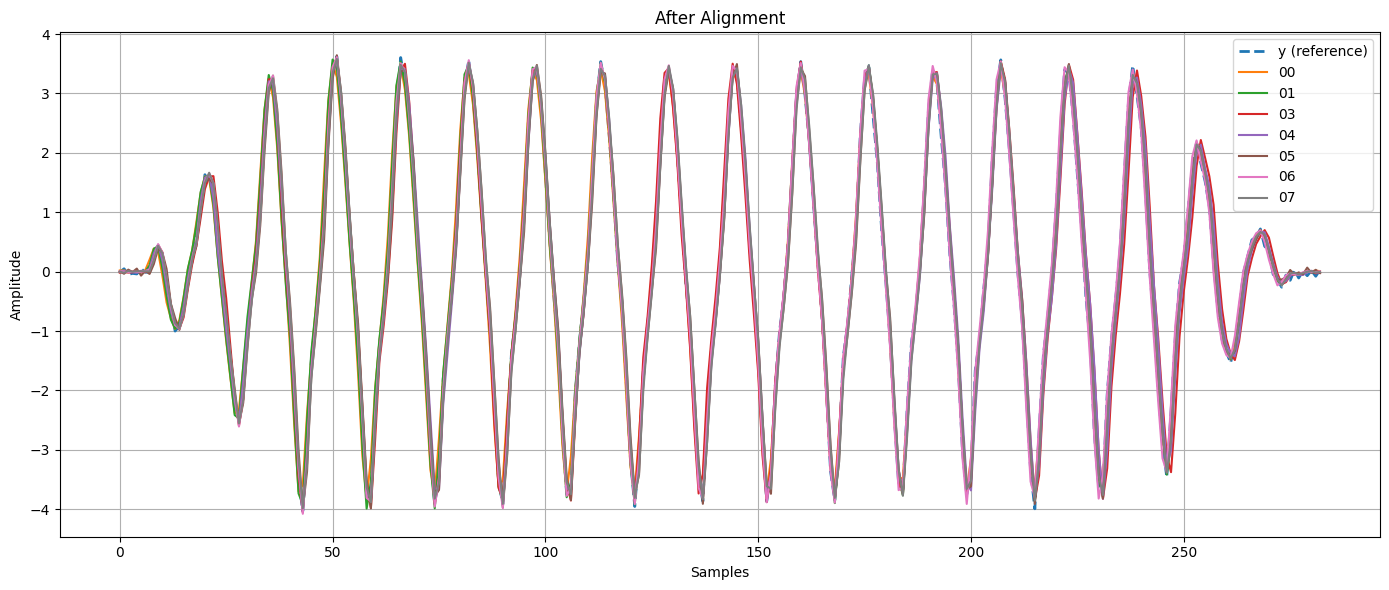

✅ Aligned signals saved to 'aligned_signals.csv'.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate

def align_to_reference(reference, signals):
    aligned_signals = []

    for signal in signals:
        correlation = correlate(signal, reference, mode='full')
        lag = correlation.argmax() - (len(reference) - 1)

        if lag > 0:
            aligned = signal[lag:]
            ref_aligned = reference[:len(aligned)]
        else:
            ref_aligned = reference[-lag:]
            aligned = signal[:len(ref_aligned)]

        min_len = min(len(ref_aligned), len(aligned))
        aligned = aligned[:min_len]
        aligned_signals.append(aligned)

    # Force output to 2D (signals, samples)
    aligned_signals = np.atleast_2d(aligned_signals)

    return aligned_signals

def plot_signals(reference, signals, signal_names, title):
    plt.figure(figsize=(14, 6))
    plt.title(title)
    plt.plot(reference, label='y (reference)', linewidth=2, linestyle='--')

    for signal, name in zip(signals, signal_names):
        plt.plot(signal-np.mean(signal), label=name)

    plt.legend()
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    new_rate = 100
    acc= "0.4"
    freq="6.4"
    # Example signals (replace these with your real signals)
    y = pd.read_csv("sensor/11-"+acc+"-"+freq+".csv")['Acceleration x (m/s^2)'].values
    x0 = pd.read_csv("redmi/00-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x0) * new_rate / 195)
    x0 = resample(x0, num_samples)

    x1 = pd.read_csv("A51/01-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x1) * new_rate / 500)
    x1 = resample(x1, num_samples)

    #x2 = pd.read_csv("poco/02-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    #num_samples = int(len(x2) * new_rate / 419)
    #x2 = resample(x2, num_samples)

    x3 = pd.read_csv("A5(1)/03-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x3) * new_rate / 196)
    x3 = resample(x3, num_samples)

    x4 = pd.read_csv("A5(2)/04-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x4) * new_rate / 196)
    x4 = resample(x4, num_samples)

    x5 = pd.read_csv("huawei/05-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x5) * new_rate / 250)
    x5 = resample(x5, num_samples)

    x6 = pd.read_csv("S8/06-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values
    num_samples = int(len(x6) * new_rate / 500)
    x6 = resample(x6, num_samples)

    x7 = pd.read_csv("SE/07-"+acc+"-"+freq+".CSV")['Acceleration x (m/s^2)'].values

    
    # Create x5 to x8 if needed

    signals = [x0,x1, x3, x4,x5,x6,x7]  # Add x5, ..., x8 here
    signal_names = ['00','01', '03', '04','05','06','07']  # Names for plotting and CSV

    # Plot signals before alignment
    plot_signals(y, signals, signal_names, title="Before Alignment")

    # Align signals
    aligned_signals = align_to_reference(y, signals)

    # Cut reference to match the aligned signals' length
    y_cut = y[:aligned_signals.shape[1]]

    # Plot signals after alignment
    plot_signals(y_cut, aligned_signals, signal_names, title="After Alignment")

    # Save aligned signals + reference to CSV
    all_signals = np.vstack([y_cut, aligned_signals])  # First row: reference
    columns = ['11'] + signal_names

    df = pd.DataFrame(all_signals.T, columns=columns)
    df.to_csv("alignment/"+acc+"-"+freq+".csv", index=False)

    print("✅ Aligned signals saved to 'aligned_signals.csv'.")


In [5]:
import os
import pandas as pd
import numpy as np
from scipy.signal import resample, correlate

# Mapping from id to original sampling rates
original_rates = {
    "00": 195,
    "01": 500,
    "02": 419,
    "03": 196,
    "04": 196,
    "05": 250,
    "06": 500,
    "07": 100
}

def resample_dataframe(df, original_rate, target_rate=100):
    num_samples = int(len(df) * target_rate / original_rate)
    resampled_data = {}

    for column in df.columns:
        resampled_data[column] = resample(df[column].values, num_samples)

    return pd.DataFrame(resampled_data)

def align_full_file(file_path, reference_path, output_folder, file_id):
    # Read both files
    df = pd.read_csv(file_path)
    df_ref = pd.read_csv(reference_path)

    # Resample both to 100 Hz
    original_rate = original_rates.get(file_id)
    if original_rate is None:
        print(f"⚠️ Unknown sampling rate for {file_id}. Skipping.")
        return

    # Get reference's original rate (always 100 for id '11')
    ref_original_rate = 100  # Assuming reference is already at 100 Hz

    df_resampled = resample_dataframe(df, original_rate)
    df_ref_resampled = resample_dataframe(df_ref, ref_original_rate)

    # Align based on 'Acceleration x (m/s^2)' column
    signal = df_resampled['Acceleration x (m/s^2)'].values
    ref_signal = df_ref_resampled['Acceleration x (m/s^2)'].values

    correlation = correlate(signal, ref_signal, mode='full')
    lag = correlation.argmax() - (len(ref_signal) - 1)

    if lag > 0:
        df_aligned = df_resampled.iloc[lag:].reset_index(drop=True)
        df_ref_aligned = df_ref_resampled.iloc[:len(df_aligned)].reset_index(drop=True)
    else:
        df_ref_aligned = df_ref_resampled.iloc[-lag:].reset_index(drop=True)
        df_aligned = df_resampled.iloc[:len(df_ref_aligned)].reset_index(drop=True)

    # Match lengths exactly
    min_len = min(len(df_aligned), len(df_ref_aligned))
    df_aligned = df_aligned.iloc[:min_len]

    # Save aligned file
    filename = os.path.basename(file_path)
    output_path = os.path.join(output_folder, filename)
    df_aligned.to_csv(output_path, index=False)
    print(f"✅ Resampled, aligned, and saved: {output_path}")

def process_all_files(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            file_id = filename.split('-')[0]
            input_path = os.path.join(input_folder, filename)

            # Build reference file path
            parts = filename.split('-')
            if len(parts) < 3:
                print(f"⚠️ Skipping file (unexpected name format): {filename}")
                continue
            reference_filename = '11-' + '-'.join(parts[1:])
            reference_path = os.path.join(input_folder, reference_filename)

            if not os.path.exists(reference_path):
                print(f"❌ Reference file not found for {filename}: expected {reference_filename}")
                continue

            # Align and save
            align_full_file(input_path, reference_path, output_folder, file_id)

# Example run
if __name__ == "__main__":
    input_folder = "all data"  # Folder where your original files are
    output_folder = "aligned"  # Where the new aligned, resampled files will go

    process_all_files(input_folder, output_folder)


✅ Resampled, aligned, and saved: aligned\00-0.1-2.csv
✅ Resampled, aligned, and saved: aligned\00-0.1-6.4.csv
✅ Resampled, aligned, and saved: aligned\00-0.2-2.csv
✅ Resampled, aligned, and saved: aligned\00-0.2-6.4.csv
✅ Resampled, aligned, and saved: aligned\00-0.3-6.4.csv
✅ Resampled, aligned, and saved: aligned\00-0.4-4.csv
✅ Resampled, aligned, and saved: aligned\00-0.4-6.4.csv
✅ Resampled, aligned, and saved: aligned\00-0.5-6.4.csv
✅ Resampled, aligned, and saved: aligned\00-0.7-6.4.csv
✅ Resampled, aligned, and saved: aligned\01-0.1-2.csv
✅ Resampled, aligned, and saved: aligned\01-0.1-6.4.csv
✅ Resampled, aligned, and saved: aligned\01-0.2-2.csv
✅ Resampled, aligned, and saved: aligned\01-0.2-4.csv
✅ Resampled, aligned, and saved: aligned\01-0.2-6.4.csv
✅ Resampled, aligned, and saved: aligned\01-0.3-6.4.csv
✅ Resampled, aligned, and saved: aligned\01-0.4-4.csv
✅ Resampled, aligned, and saved: aligned\01-0.4-6.4.csv
✅ Resampled, aligned, and saved: aligned\01-0.5-6.4.csv
✅ Resa

In [6]:
import os
import pandas as pd
import numpy as np
from scipy.signal import resample

# Mapping from id to original sampling rates
original_rates = {
    "00": 195,
    "01": 500,
    "02": 419,
    "03": 196,
    "04": 196,
    "05": 250,
    "06": 500,
    "07": 100
}

def resample_dataframe(df, original_rate, target_rate=100):
    num_samples = int(len(df) * target_rate / original_rate)
    resampled_data = {}

    for column in df.columns:
        resampled_data[column] = resample(df[column].values, num_samples)

    return pd.DataFrame(resampled_data)

def resample_all_files(input_folder, output_folder, target_rate=100):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            file_id = filename.split('-')[0]
            input_path = os.path.join(input_folder, filename)

            original_rate = original_rates.get(file_id)
            if original_rate is None:
                print(f"⚠️ Unknown sampling rate for {file_id}. Skipping {filename}.")
                continue

            # Read the file
            df = pd.read_csv(input_path)

            # Resample all columns
            df_resampled = resample_dataframe(df, original_rate, target_rate)

            # Save to new folder
            output_path = os.path.join(output_folder, filename)
            df_resampled.to_csv(output_path, index=False)
            print(f"✅ Resampled and saved: {output_path}")

# Example run
if __name__ == "__main__":
    input_folder = "all data"   # Your original folder
    output_folder = "resampled"  # Your output folder for resampled files

    resample_all_files(input_folder, output_folder)


✅ Resampled and saved: resampled\00-00-00.csv
✅ Resampled and saved: resampled\01-00-00.csv
✅ Resampled and saved: resampled\02-00-00.csv
✅ Resampled and saved: resampled\03-00-00.csv
✅ Resampled and saved: resampled\04-00-00.csv
✅ Resampled and saved: resampled\05-00-00.csv
✅ Resampled and saved: resampled\06-00-00.csv
